# Разработка A/B-тестирования и анализ результатов

**Цель:** оценить влияние нового алгоритма рекомендаций на вовлечённость пользователей и принять решение о его внедрении.

**Задачи:**
- Провести исследовательский анализ исторических данных.
- Рассчитать параметры A/B-теста и проверить корректность его проведения.
- Оценить влияние нового алгоритма на ключевую метрику и статистическую значимость результата.
- Сформулировать рекомендацию по внедрению алгоритма.

## Описание данных

В работе используются данные о сессиях пользователей развлекательного приложения:

- **Исторические данные** - используются для исследовательского анализа, оценки текущего уровня метрик и расчёта параметров A/B-теста.
- **Данные первого дня эксперимента** - используются для проверки корректности распределения пользователей по группам.
- **Данные A/B-теста за весь период** - используются для оценки ключевой метрики и статистической значимости результатов.

## Содержание

1. Работа с историческими данными (EDA)
2. Подготовка к тесту
3. Мониторинг A/B-теста
4. Проверка результатов A/B-теста
5. Вывод по результатам A/B-эксперимента

## 1. Работа с историческими данными (EDA)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

### Знакомство с данными 

In [2]:
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [3]:
# Расчитываем количество уникальных сессий для каждого пользователя и выводим с наибольшим количеством сессий
max_user_id = sessions_history.groupby('user_id')['session_id'].nunique().sort_values(ascending=False).idxmax()
max_user_id

'10E0DEFC1ABDBBE0'

In [4]:
# Выводим структуру данных по этому пользователю
sessions_history.loc[sessions_history['user_id'] == max_user_id]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


**Вывод:** Пользователь 10E0DEFC1ABDBBE0 совершил 10 уникальных сессий - это максимальное количество сессий среди пользователей в исторических данных. По данным пользователя видно, что session_number последовательно увеличивается от 1 до 10, а install_date остаётся неизменной, что соответствует логике формирования данных.

### Анализ числа регистраций

In [5]:
# Рассчитываем по каждому дню количество уникальных пользователей и регистраций
daily_users = sessions_history.groupby('session_date').agg({'user_id': 'nunique',
                                                            'registration_flag': 'sum'})
daily_users.head()

,user_id,registration_flag
session_date,,
2025-08-11,3919,169
2025-08-12,6056,336
2025-08-13,8489,464
2025-08-14,10321,625
2025-08-15,14065,840


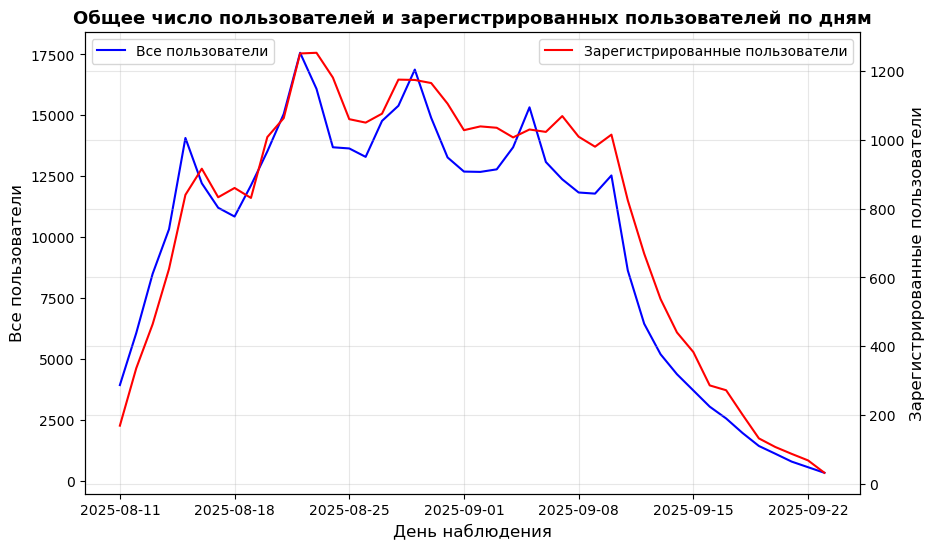

In [6]:
# Строим графики количества уникальных пользователей и регистраций по дням
fig, ax1 = plt.subplots(figsize=(10, 6))

# Все пользователи
ax1.plot(
    daily_users.index,
    daily_users['user_id'],
    label='Все пользователи',
    color = 'blue')
    


ax1.set_xlabel('День наблюдения',fontsize=12)
ax1.set_ylabel('Все пользователи',fontsize=12)

# Зарегистрированные пользователи
ax2 = ax1.twinx()
ax2.plot(
    daily_users.index,
    daily_users['registration_flag'],
    label='Зарегистрированные пользователи',
    color = 'red')
                                      


ax2.set_ylabel('Зарегистрированные пользователи',fontsize=12)

plt.xticks(
    ticks=daily_users.index[::7],
    rotation=50)

plt.title('Общее число пользователей и зарегистрированных пользователей по дням',
    fontsize=13,
    fontweight='bold')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.grid(axis='x',alpha=0.3)   
ax2.grid(axis='y',alpha=0.3)

plt.show()

**Вывод:** Количество пользователей и регистраций в начале периода росло, достигнув максимальных значений примерно в конце августа - начале сентября. После этого наблюдается устойчивое снижение показателей, особенно заметное во второй половине сентября. Возможными причинами могут быть снижение притока новых пользователей, сезонность или изменение источников трафика.

In [7]:
# Доля регистраций
daily_users['registration_share'] = daily_users['registration_flag']/daily_users['user_id']
daily_users.head()

,user_id,registration_flag,registration_share
session_date,,,
2025-08-11,3919,169,0.043123
2025-08-12,6056,336,0.055482
2025-08-13,8489,464,0.054659
2025-08-14,10321,625,0.060556
2025-08-15,14065,840,0.059723


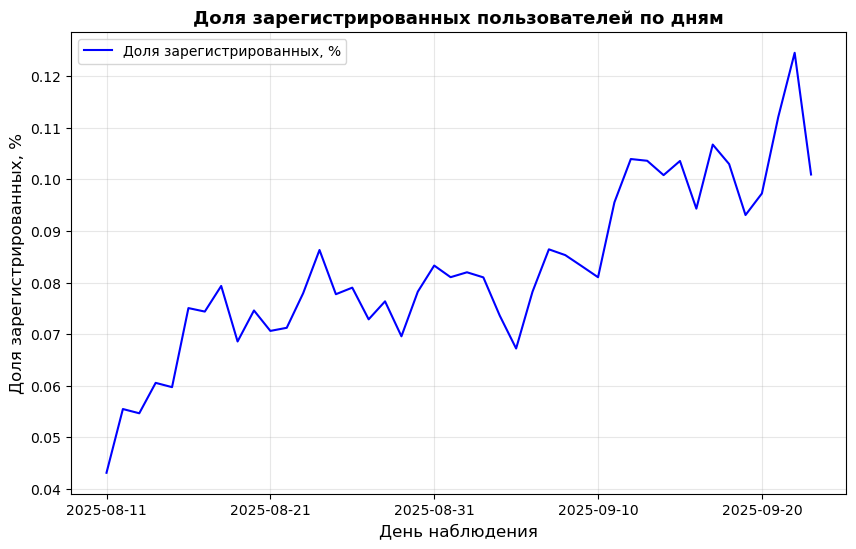

In [8]:
daily_users['registration_share'].plot(kind='line',
                                       figsize=(10, 6),
                                       color = 'blue')
                    
plt.title('Доля зарегистрированных пользователей по дням',
         fontsize=13,
         fontweight='bold')
plt.xlabel('День наблюдения',fontsize=12)
plt.ylabel('Доля зарегистрированных, %',fontsize=12)
plt.grid(alpha=0.3)
plt.legend(['Доля зарегистрированных, %'])

plt.show()

**Вывод:** Доля зарегистрированных пользователей в целом колеблется в пределах примерно 6–9%. В начале периода наблюдается рост показателя, затем он становится относительно стабильным, а к концу периода заметна повышенная волатильность на фоне резкого снижения общего числа пользователей.

### Анализ числа просмотренных страниц во время первых сессий пользователей

In [9]:
# Фильтр по первой сессии
first_session = sessions_history.loc[sessions_history['session_number']==1]
# Группировка страниц и сессий
first_session_pages = first_session.groupby('page_counter')['session_id'].nunique()
first_session_pages

page_counter
1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: session_id, dtype: int64

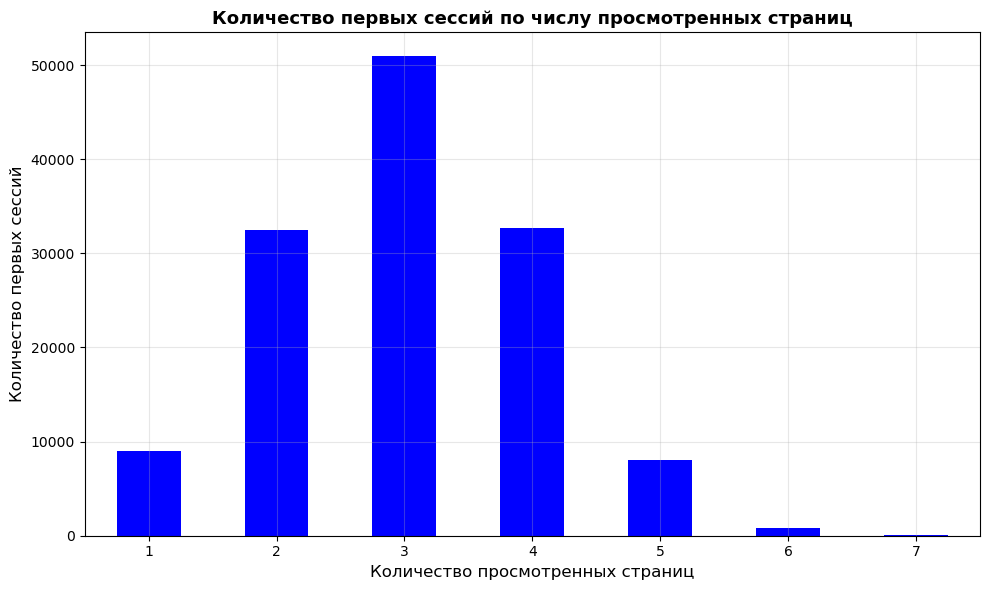

In [10]:
# Строим график
first_session_pages.plot(kind = 'bar',
                         figsize=(10, 6),
                         color = 'blue')

plt.title('Количество первых сессий по числу просмотренных страниц',
         fontsize=13,
         fontweight='bold')
plt.xlabel('Количество просмотренных страниц',fontsize=12)
plt.ylabel('Количество первых сессий',fontsize=12)
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:** Наибольшее количество первых сессий приходится на 3 просмотренные страницы - 50 939 сессий. Далее идут 4 страницы - 32 739 и 2 страницы - 32 494. При этом сессий с 5 и более страницами значительно меньше, а 6-7 страниц встречаются редко.

Основная масса пользователей в первой сессии просматривает от 2 до 4 страниц, а более глубокое взаимодействие с лентой встречается значительно реже.

### Доля пользователей, просмотревших более четырёх страниц

In [11]:
# Создаём признак успешной сессии: 1 - просмотрено 4 и более страниц, 0 - менее 4
sessions_history['good_session'] = np.where(sessions_history['page_counter'] >= 4, 1, 0)
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


In [12]:
# Отбираем первые сессии пользователей
firct_session = sessions_history.loc[sessions_history['session_number'] ==1]

# Рассчитываем по дням количество успешных первых сессий и общее количество первых сессий
daily_data = firct_session.groupby('session_date').agg({'good_session':'sum',
                                                        'session_id' : 'nunique'})
# Рассчитываем долю успешных первых сессий по дням
daily_data['share_good_session']= daily_data['good_session']/daily_data['session_id']
daily_data.head()

,good_session,session_id,share_good_session
session_date,,,
2025-08-11,1226,3919,0.312835
2025-08-12,1225,4106,0.298344
2025-08-13,1561,5087,0.306861
2025-08-14,1741,5456,0.319098
2025-08-15,2427,7801,0.311114


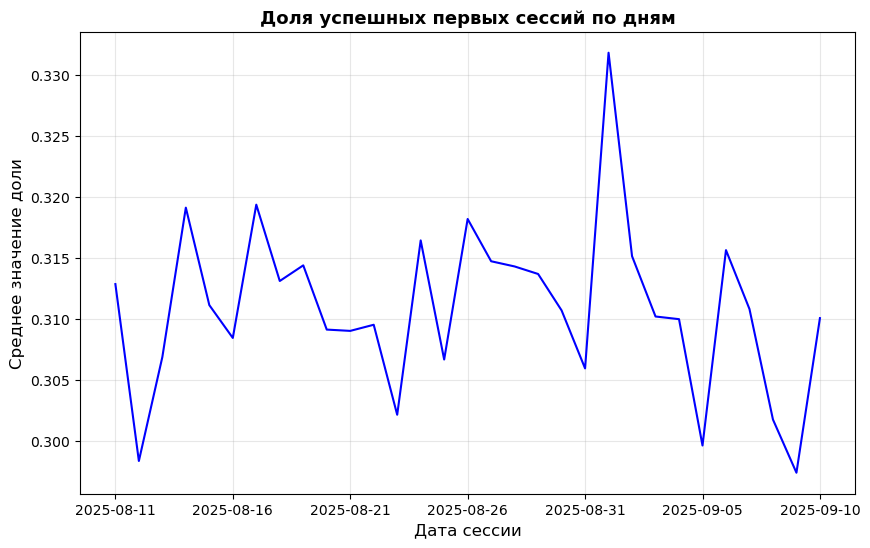

In [13]:
# Строим график успешных первых сессий
daily_data['share_good_session'].plot(kind = 'line',
                                      figsize=(10, 6),
                                      color = 'blue')
                                

plt.title('Доля успешных первых сессий по дням', fontsize=13,fontweight='bold')
plt.xlabel('Дата сессии', fontsize=12)
plt.ylabel('Среднее значение доли', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

**Вывод:** Доля пользователей, просмотревших более 4 страниц, заметно меняется в течение периода. В отдельные дни показатель достигает более высоких значений, после чего снижается. При этом выраженного устойчивого тренда на рост или снижение доли не наблюдается.

## 2. Подготовка к тесту

**На этапе подготовки мы:**

* Определим ключевую метрику и сформулируем гипотезы.
* Рассчитаем необходимый размер выборки с учётом MDE и мощности теста.
* Определим необходимую длительность эксперимента исходя из среднего дневного трафика.
* Проверим корректность распределения пользователей между группами A и B.

### Расчёт размера выборки

In [14]:
# Параметры A/B-теста

alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03  # MDE - 3% от базового уровня

# Рассчитываем стандартизированный размер эффекта
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем расчёт мощности теста
power_analysis = NormalIndPower()

# Рассчитываем необходимый размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


### Расчёт длительности A/B-теста

In [15]:
# Рассчитываем среднее количество уникальных пользователей в день
avg_daily_users = ceil(sessions_history.groupby('session_date')['user_id'].nunique().mean())
avg_daily_users

# Рассчитываем необходимую длительность A/B-теста
test_duration = ceil((sample_size*2)/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9908 пользователей в день составит 9 дней


## 3. Мониторинг A/B-теста

### Проверка распределения пользователей

In [16]:
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [17]:
test_group = sessions_test_part.groupby('test_group')['user_id'].nunique()
test_group

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [18]:
# Процентная разница между группами
percentage_difference = round(100*(test_group['A'] - test_group['B'])/test_group['A'], 2)
print(f'Процентная разница между группами А и В = {percentage_difference} %')

Процентная разница между группами А и В = 0.74 %


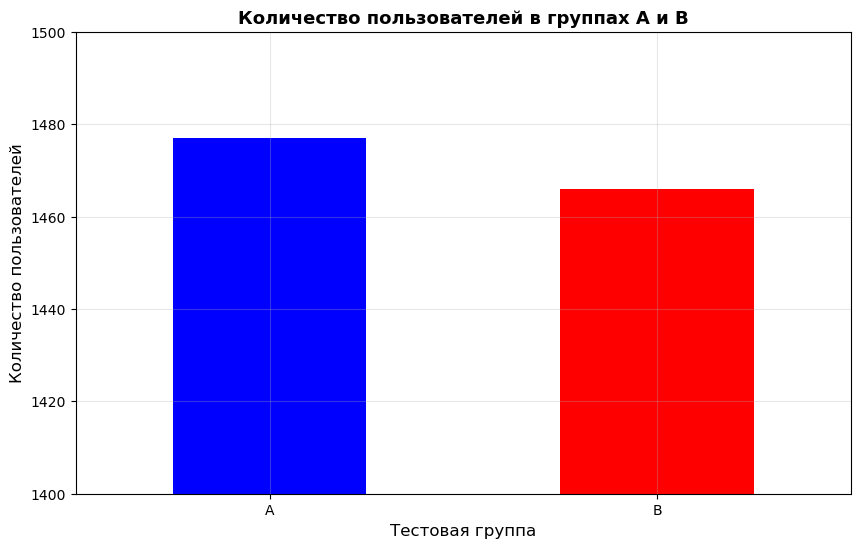

In [19]:
# Строим график по количеству пользователей в группах
test_group.plot(kind='bar',
                figsize=(10, 6),
                color=['blue', 'red'])

plt.title('Количество пользователей в группах A и B',fontsize=13,fontweight='bold')
plt.xlabel('Тестовая группа',fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.grid(alpha =0.3)
plt.xticks(rotation=0)
plt.ylim(1400, 1500)
plt.show()

### Проверка пересечений пользователей

In [20]:
user_a = set(sessions_test_part.loc[sessions_test_part['test_group']== 'A']['user_id'])
user_b = set(sessions_test_part.loc[sessions_test_part['test_group']== 'B']['user_id'])  
len(user_a & user_b)

0

### Равномерность разделения пользователей по устройствам

Строим два графика:

* доля каждого типа устройства для пользователей из группы A,
* доля каждого типа устройства для пользователей из группы B.

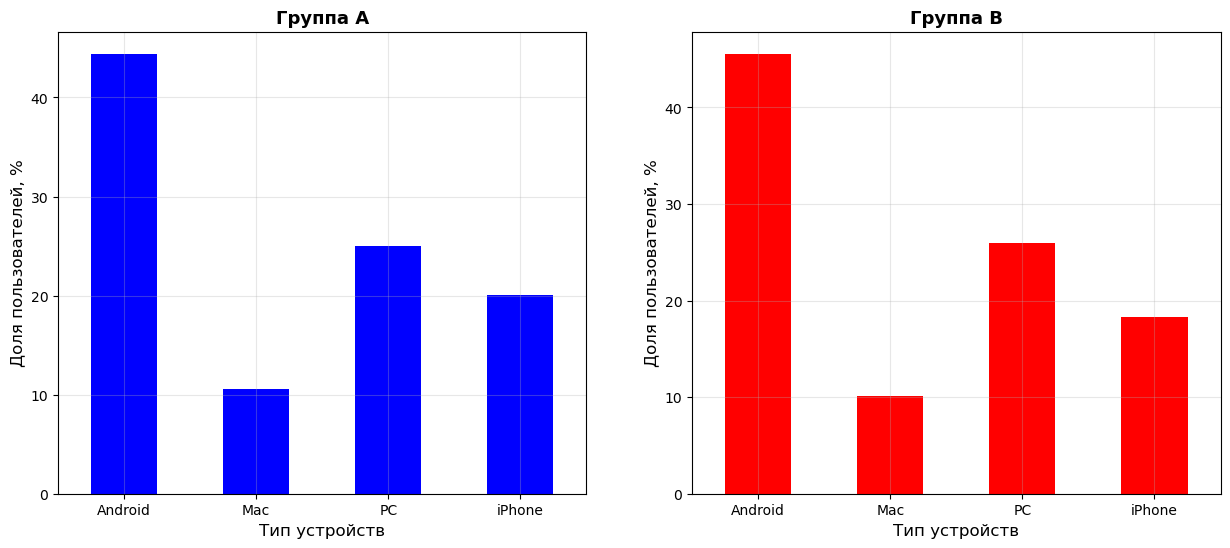

In [21]:
device_a = sessions_test_part.loc[sessions_test_part['test_group']=='A'].groupby('device')['user_id'].nunique()
device_b = sessions_test_part.loc[sessions_test_part['test_group']=='B'].groupby('device')['user_id'].nunique()

device_share_a = device_a/device_a.sum()*100
device_share_b = device_b/device_b.sum()*100

# Создаем области
fig, ax = plt.subplots(1,2, figsize=(15, 6))
# Первый граффик
device_share_a.plot(kind = 'bar',
             ax = ax[0],
             color = 'blue')
# Второй граффик
device_share_b.plot(kind = 'bar',
             ax = ax[1],
             color = 'red')

ax[0].set_title('Группа А',fontsize=13,fontweight='bold')
ax[1].set_title('Группа B',fontsize=13,fontweight='bold')

ax[0].set_xlabel('Тип устройств',fontsize=12)
ax[1].set_xlabel('Тип устройств',fontsize=12)

ax[0].set_ylabel('Доля пользователей, %',fontsize=12)
ax[1].set_ylabel('Доля пользователей, %',fontsize=12)

ax[0].tick_params(axis='x', rotation=0)
ax[1].tick_params(axis='x', rotation=0)

ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)

plt.show()

**Вывод:** распределение пользователей по типам устройств в группах A и B визуально схоже. Существенных различий в долях пользователей по типам устройств между группами не наблюдается.

### Равномерность распределения пользователей по регионам

Строим два графика:
* доля каждого региона для пользователей из группы A,
* доля каждого региона для пользователей из группы B.

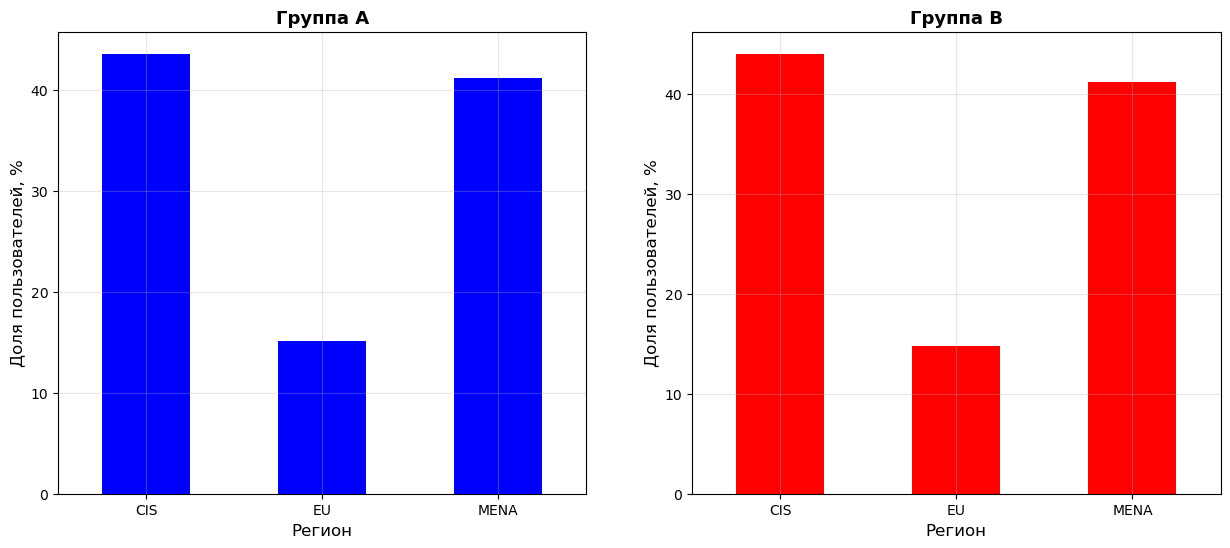

In [22]:
region_a = sessions_test_part.loc[sessions_test_part['test_group']=='A'].groupby('region')['user_id'].nunique()
region_b = sessions_test_part.loc[sessions_test_part['test_group']=='B'].groupby('region')['user_id'].nunique()

region_share_a = region_a /region_a .sum()*100
region_share_b = region_b/region_b.sum()*100

# Создаем области
fig, ax = plt.subplots(1,2, figsize=(15, 6))
# Первый граффик
region_share_a.plot(kind = 'bar',
             ax = ax[0],
             color = 'blue')
# Второй граффик
region_share_b.plot(kind = 'bar',
             ax = ax[1],
             color = 'red')

ax[0].set_title('Группа А',fontsize=13,fontweight='bold')
ax[1].set_title('Группа B',fontsize=13,fontweight='bold')

ax[0].set_xlabel('Регион',fontsize=12)
ax[1].set_xlabel('Регион',fontsize=12)

ax[0].set_ylabel('Доля пользователей, %',fontsize=12)
ax[1].set_ylabel('Доля пользователей, %',fontsize=12)

ax[0].tick_params(axis='x', rotation=0)
ax[1].tick_params(axis='x', rotation=0)

ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)

plt.show()

**Вывод:** распределение пользователей по регионам в группах A и B визуально схоже. Существенных различий в долях пользователей по регионам между группами не наблюдается.

### Вывод после проверки A/B-теста

В группе A находится 1477 пользователей, в группе B - 1466 пользователей. Разница между группами составляет около 0,74%, поэтому группы имеют сопоставимый размер.

Пересечения пользователей между группами A и B не обнаружено. Следовательно, выборки являются независимыми, и один пользователь не попал одновременно в обе группы.

Распределение пользователей по типам устройств в группах A и B визуально схоже. Существенных различий в долях пользователей по устройствам не наблюдается.

Распределение пользователей по регионам также визуально схоже. Существенных различий между группами не обнаружено.

**Итог:** по проверенным параметрам нарушений при формировании групп не обнаружено. Группы имеют сопоставимый размер, пользователи не пересекаются, а распределение по устройствам и регионам примерно одинаковое. A/B-тест можно считать корректно сформированным и пригодным для дальнейшего анализа результатов эксперимента.

## 4. Проверка результатов A/B-теста

In [23]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

# Создаём признак успешной сессии: 1 - просмотрено 4 и более страниц, 0 - менее 4
sessions_test['good_session'] = np.where(sessions_test['page_counter'] >= 4, 1, 0)
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


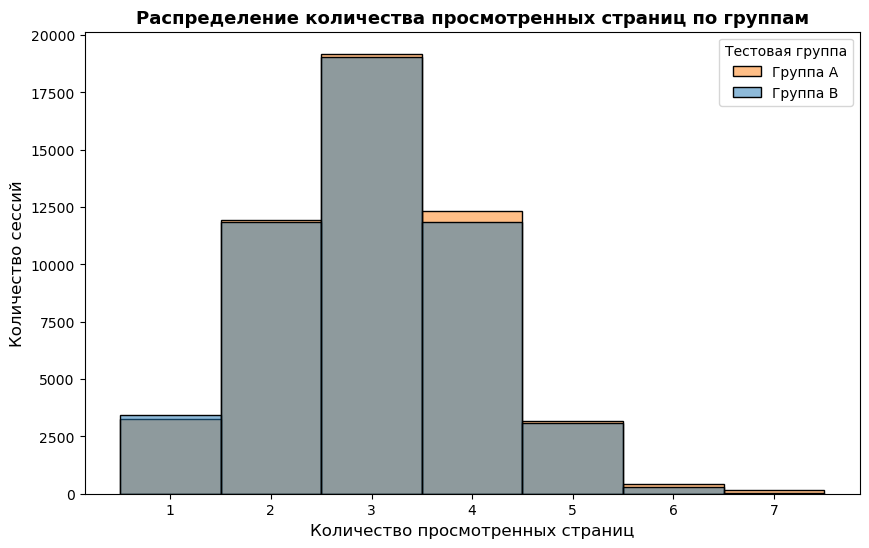

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=sessions_test,
    x='page_counter',
    hue='test_group',
    discrete=True)

plt.title('Распределение количества просмотренных страниц по группам', fontsize=13,fontweight='bold')
plt.xlabel('Количество просмотренных страниц', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.legend(title='Тестовая группа', labels=['Группа A', 'Группа B'])
plt.show()

**Вывод:** Распределение количества просмотренных страниц в группах A и B схожее. Большинство сессий приходится на 2-4 просмотренные страницы, максимальное количество - на 3 страницы. После 4 страниц число сессий заметно снижается, существенных различий между группами не наблюдается.

### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси и барьерных метрик

**Гипотезы**

* H₀: доля успешных первых сессий в группах A и B не различается.

* H₁: доля успешных первых сессий в группе B выше, чем в группе A.

**Метрики**

* Ключевая: доля успешных первых сессий (4+ просмотренных страниц).
* Прокси: среднее количество сессий на пользователя.
* Барьерная: доля пользователей, оформивших платную подписку.

### Сравнение доли успешных первых сессий

In [31]:
group_a = sessions_test.loc[(sessions_test['test_group'] == 'A') & (sessions_test['session_number']==1)]
group_b = sessions_test.loc[(sessions_test['test_group'] == 'B') & (sessions_test['session_number']==1)]

good_session_a = round(group_a['good_session'].sum()/len(group_a)*100, 2)
good_session_b = round(group_b['good_session'].sum()/len(group_b)*100, 2)

difference_b_a = round(good_session_b - good_session_a, 2)

print(f'Доля успешных сессий группы А = {good_session_a} %')
print(f'Доля успешных сессий группы B = {good_session_b} %')
print(f'Разница результатов группы B и А = {difference_b_a} %')

Доля успешных сессий группы А = 31.57 %
Доля успешных сессий группы B = 31.47 %
Разница результатов группы B и А = -0.1 %


### Cтатистическая значимость изменение ключевой метрики

In [32]:
#Общее количество выборок А и В
n_a, n_b = len(group_a), len(group_b)
# Количество успехов
m_a, m_b = group_a['good_session'].sum(), group_b['good_session'].sum()

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative = 'smaller')

print(f'p_value ={p_value_ztest}')

if p_value_ztest < alpha:
    print(f'Статистически значимое различие обнаружено: p-value = {p_value_ztest} < alpha = {alpha}.\nНулевая гипотеза отвергается в пользу альтернативной.')
else:
    print(f'Статистически значимого различия не обнаружено: p-value = {p_value_ztest} > alpha = {alpha}.\nНулевая гипотеза не отвергается.')

p_value =0.5783523649187868
Статистически значимого различия не обнаружено: p-value = 0.5783523649187868 > alpha = 0.05.
Нулевая гипотеза не отвергается.


## 5. Вывод по результатам A/B-эксперимента

* Период эксперимента: общая длительность - 20 дней. Пользователи были распределены между контрольной группой A и тестовой группой B.
* Ключевая метрика: доля успешных первых сессий составила 31,57% в группе A и 31,47% в группе B. В тестовой группе показатель снизился на 0,10 процентного пункта, поэтому ожидаемого роста ключевой метрики не наблюдается.
* Статистическая значимость: полученное значение p-value = 0,578 значительно превышает выбранный уровень значимости α = 0,05. Следовательно, оснований отвергнуть нулевую гипотезу нет - статистически значимого различия между группами не обнаружено.
* Результат эксперимента: новый алгоритм рекомендаций не продемонстрировал статистически значимого улучшения ключевой метрики по сравнению с текущим алгоритмом.
* Решение: на основании проведённого эксперимента внедрять новый алгоритм не рекомендуется, поскольку полученный результат не подтверждает гипотезу о повышении вовлечённости пользователей.